In [ ]:
# prompt: import data science libraries, sns set theme, mount drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

sns.set_theme()

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data_path = '/content/drive/My Drive/Colab Notebooks/dso574/NBA/'

In [ ]:
files = os.listdir(data_path + 'Combined Files [With Game ID]')
files

['2016-2017_NBA_PbP_Logs.csv',
 '2014-2015_NBA_PbP_Logs.csv',
 '2013-2014_NBA_PbP_Logs.csv',
 '2015-2016_NBA_PbP_Logs.csv',
 '2021-2022_NBA_PbP_Logs.csv',
 '2017-2018_NBA_PbP_Logs.csv',
 '2019-2020_NBA_PbP_Logs.csv',
 '2022-2023_NBA_PbP_Logs.csv',
 '2018-2019_NBA_PbP_Logs.csv',
 '2020-2021_NBA_PbP_Logs.csv',
 '2023-2024_NBA_PbP_Logs.csv']

In [ ]:
df = pd.read_csv(data_path + 'Combined Files [With Game ID]/2014-2015_NBA_PbP_Logs.csv')

In [ ]:
new_orleans = df[df['matchup'].apply(lambda x: 'NOP' in x)].copy()
new_orleans['ad_on'] = (new_orleans.iloc[:, 3:14] == 'Anthony Davis').sum(axis=1).astype(bool)
new_orleans['NOP_offense'] = new_orleans.team == 'NOP'
new_orleans['game_min'] = new_orleans.elapsed.apply(lambda x: int(x.split(':')[1]))
new_orleans

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,original_x,original_y,converted_x,converted_y,description,matchup,game_name,ad_on,NOP_offense,game_min
4480,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,NaN,NaN,NaN,NaN,NaN,NOP@DAL,0021400323-NOP@DAL,True,False,0
4481,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,NaN,NaN,NaN,NaN,Jump Ball Chandler vs. Davis: Tip to Barea,NOP@DAL,0021400323-NOP@DAL,True,False,0
4482,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,9.0,98.0,25.9,79.2,MISS Ellis 10' Jump Shot,NOP@DAL,0021400323-NOP@DAL,True,False,0
4483,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,NaN,NaN,NaN,NaN,Asik REBOUND (Off:0 Def:1),NOP@DAL,0021400323-NOP@DAL,True,True,0
4484,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,-168.0,121.0,41.8,17.1,Davis 21' Jump Shot (2 PTS) (Holiday 1 AST),NOP@DAL,0021400323-NOP@DAL,True,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600094,21400311,2014-15 Regular Season,2014-12-09,Amar'e Stoudemire,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,NaN,NaN,NaN,NaN,Asik Free Throw 1 of 2 (16 PTS),NYK@NOP,0021400311-NYK@NOP,True,True,11
600095,21400311,2014-15 Regular Season,2014-12-09,Amar'e Stoudemire,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,NaN,NaN,NaN,NaN,MISS Asik Free Throw 2 of 2,NYK@NOP,0021400311-NYK@NOP,True,True,11
600096,21400311,2014-15 Regular Season,2014-12-09,Cole Aldrich,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,NaN,NaN,NaN,NaN,Anthony REBOUND (Off:1 Def:7),NYK@NOP,0021400311-NYK@NOP,True,False,11
600097,21400311,2014-15 Regular Season,2014-12-09,Cole Aldrich,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,-15.0,9.0,26.5,5.9,Smith 2' Driving Layup (17 PTS),NYK@NOP,0021400311-NYK@NOP,True,False,11


In [ ]:
new_orleans.columns

Index(['game_id', 'data_set', 'date', 'a1', 'a2', 'a3', 'a4', 'a5', 'h1', 'h2',
       'h3', 'h4', 'h5', 'period', 'away_score', 'home_score',
       'remaining_time', 'elapsed', 'play_length', 'play_id', 'team',
       'event_type', 'assist', 'away', 'home', 'block', 'entered', 'left',
       'num', 'opponent', 'outof', 'player', 'points', 'possession', 'reason',
       'result', 'steal', 'type', 'shot_distance', 'original_x', 'original_y',
       'converted_x', 'converted_y', 'description', 'matchup', 'game_name',
       'ad_on', 'NOP_offense', 'game_min'],
      dtype='object')

## KD to the Suns Effect on DBook

In [ ]:
years = ['2021-2022_NBA_PbP_Logs.csv', '2022-2023_NBA_PbP_Logs.csv', '2023-2024_NBA_PbP_Logs.csv']
suns = pd.DataFrame()
for y in years:
  data = pd.read_csv(data_path + 'Combined Files [With Game ID]/' + y)
  suns = pd.concat([suns, data[data['matchup'].apply(lambda x: 'PHX' in x)]])
suns

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,steal,type,shot_distance,original_x,original_y,converted_x,converted_y,description,matchup,game_name
2287,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,start of period,NaN,NaN,NaN,NaN,NaN,NaN,DET@PHX,0022100331-DET@PHX
2288,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,jump ball,NaN,NaN,NaN,NaN,NaN,Jump Ball Ayton vs. Stewart: Tip to Bridges,DET@PHX,0022100331-DET@PHX
2289,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,jump shot,15.0,-148.0,27.0,10.2,86.3,MISS Ayton 15' Turnaround Jump Shot,DET@PHX,0022100331-DET@PHX
2290,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,rebound defensive,NaN,NaN,NaN,NaN,NaN,Hayes REBOUND (Off:0 Def:1),DET@PHX,0022100331-DET@PHX
2291,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,3pt jump bank shot,25.0,105.0,231.0,14.5,28.1,MISS Grant 25' 3PT Jump Bank Shot,DET@PHX,0022100331-DET@PHX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607909,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,shot clock,NaN,NaN,NaN,NaN,NaN,Kings Turnover: Shot Clock (T#13),SAC@PHX,0022301228-SAC@PHX
607910,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,shooting,NaN,NaN,NaN,NaN,NaN,Edwards S.FOUL (P1.PN) (B.Taylor),SAC@PHX,0022301228-SAC@PHX
607911,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,free throw 1/2,NaN,NaN,NaN,NaN,NaN,Lee Free Throw 1 of 2 (3 PTS),SAC@PHX,0022301228-SAC@PHX
607912,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,free throw 2/2,NaN,NaN,NaN,NaN,NaN,Lee Free Throw 2 of 2 (4 PTS),SAC@PHX,0022301228-SAC@PHX


In [ ]:
suns['db_on'] = (suns.iloc[:, 3:14] == 'Devin Booker').sum(axis=1).astype(bool)
suns['PHX_offense'] = suns.team == 'PHX'
suns['game_min'] = suns.elapsed.apply(lambda x: int(x.split(':')[1]))
suns['period_min'] = suns.period.astype(str) + '_' + suns.game_min.astype(str)
suns['description'] = suns.description.astype(str)

In [ ]:
suns

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,original_y,converted_x,converted_y,description,matchup,game_name,db_on,PHX_offense,game_min,period_min
2287,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,NaN,NaN,nan,DET@PHX,0022100331-DET@PHX,False,False,0,1_0
2288,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,NaN,NaN,Jump Ball Ayton vs. Stewart: Tip to Bridges,DET@PHX,0022100331-DET@PHX,False,True,0,1_0
2289,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,27.0,10.2,86.3,MISS Ayton 15' Turnaround Jump Shot,DET@PHX,0022100331-DET@PHX,False,True,0,1_0
2290,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,NaN,NaN,NaN,Hayes REBOUND (Off:0 Def:1),DET@PHX,0022100331-DET@PHX,False,False,0,1_0
2291,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,231.0,14.5,28.1,MISS Grant 25' 3PT Jump Bank Shot,DET@PHX,0022100331-DET@PHX,False,False,0,1_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607909,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,NaN,NaN,Kings Turnover: Shot Clock (T#13),SAC@PHX,0022301228-SAC@PHX,False,False,11,4_11
607910,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,NaN,NaN,Edwards S.FOUL (P1.PN) (B.Taylor),SAC@PHX,0022301228-SAC@PHX,False,False,11,4_11
607911,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,NaN,NaN,Lee Free Throw 1 of 2 (3 PTS),SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11
607912,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,NaN,NaN,NaN,Lee Free Throw 2 of 2 (4 PTS),SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11


In [ ]:
# prompt: generate pivot table on 'db_on', 'PHX_offense', and 'period_min' summing 'home_score' and 'away_score'

pivot_table = pd.pivot_table(suns, values=['home_score', 'away_score'], index=['db_on', 'data_set', 'period_min'], aggfunc='sum').reset_index()
pivot_table['plus_minus'] = pivot_table['home_score'] - pivot_table['away_score']
pivot_table

,db_on,data_set,period_min,away_score,home_score,plus_minus
0,False,2021-22 Playoffs,1_0,2,12,10
1,False,2021-22 Playoffs,1_1,30,45,15
2,False,2021-22 Playoffs,1_10,1164,1227,63
3,False,2021-22 Playoffs,1_11,1173,1384,211
4,False,2021-22 Playoffs,1_12,292,344,52
...,...,...,...,...,...,...
700,True,NBA 2024 Playoffs,4_5,3199,3327,128
701,True,NBA 2024 Playoffs,4_6,5005,5326,321
702,True,NBA 2024 Playoffs,4_7,3476,3604,128
703,True,NBA 2024 Playoffs,4_8,3450,3552,102


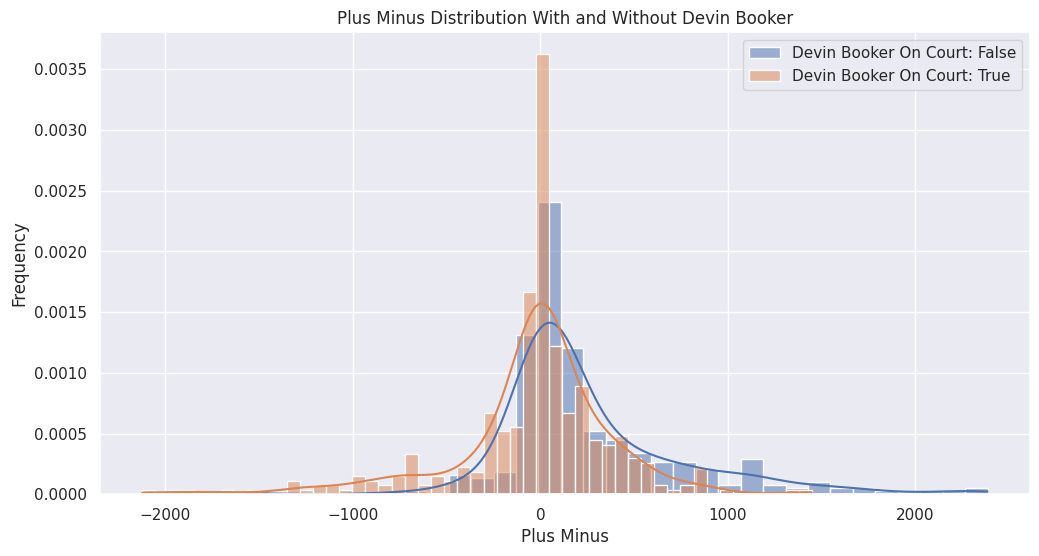

In [ ]:
# prompt:  plot plus minus distribution for both values of db_on on the same plot, remove the bars for each data_set

# Assuming pivot_table is defined as in your previous code

plt.figure(figsize=(12, 6))

for db_on_val in pivot_table['db_on'].unique():
  subset = pivot_table[pivot_table['db_on'] == db_on_val]
  sns.histplot(subset['plus_minus'], label=f'Devin Booker On Court: {db_on_val}', kde=True, stat='density')

plt.xlabel('Plus Minus')
plt.ylabel('Frequency')
plt.title('Plus Minus Distribution With and Without Devin Booker')
plt.legend()
plt.show()


### PHX Shot Percentage With and Without DBook, With and Without KD During Regular Season

In [ ]:
suns['kd_on'] = (suns.iloc[:, 3:14] == 'Kevin Durant').sum(axis=1).astype(bool)

In [ ]:
# regular season
suns_off = suns[(suns.PHX_offense) & (suns.data_set.astype(str).apply(lambda x: 'Regular' in x))].copy()
suns_off['misses'] = suns_off.description.apply(lambda x: 'MISS' in x)
suns_off['makes'] = suns_off.description.apply(lambda x: 'PTS' in x) & suns_off.description.astype(str).apply(lambda x: 'Free Throw' not in x)
suns_off.head()

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,description,matchup,game_name,db_on,PHX_offense,game_min,period_min,kd_on,misses,makes
2288,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,Jump Ball Ayton vs. Stewart: Tip to Bridges,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,False,False
2289,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,MISS Ayton 15' Turnaround Jump Shot,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,True,False
2292,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,Ayton REBOUND (Off:0 Def:1),DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,False,False
2293,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,MISS Shamet 18' Jump Shot,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,True,False
2298,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,Ayton REBOUND (Off:0 Def:2),DET@PHX,0022100331-DET@PHX,False,True,1,1_1,False,False,False


In [ ]:
# prompt: generate pivot table for suns_off for db_on and sum of misses and makes
pivot_table_suns_off_no_kd = pd.pivot_table(suns_off[~suns_off.kd_on], values=['misses', 'makes'], index=['db_on', 'period_min'], aggfunc='sum').reset_index()
pivot_table_suns_off_no_kd['shots'] = pivot_table_suns_off_no_kd['misses'] + pivot_table_suns_off_no_kd['makes']
pivot_table_suns_off_no_kd['shot_pct'] = pivot_table_suns_off_no_kd['makes'] / pivot_table_suns_off_no_kd['shots']
pivot_table_suns_off_no_kd

,db_on,period_min,makes,misses,shots,shot_pct
0,False,1_0,34,41,75,0.453333
1,False,1_1,35,45,80,0.437500
2,False,1_10,52,83,135,0.385185
3,False,1_11,78,100,178,0.438202
4,False,1_12,2,24,26,0.076923
...,...,...,...,...,...,...
111,True,5_1,3,2,5,0.600000
112,True,5_2,1,2,3,0.333333
113,True,5_3,1,2,3,0.333333
114,True,5_4,0,5,5,0.000000


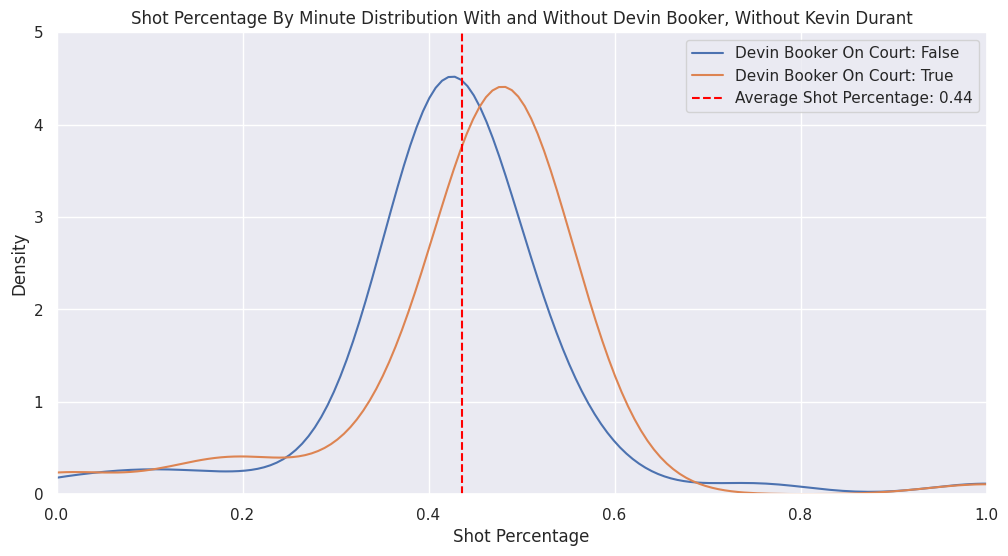

In [ ]:
plt.figure(figsize=(12, 6))

for db_on_val in pivot_table_suns_off_no_kd['db_on'].unique():
  subset = pivot_table_suns_off_no_kd[pivot_table_suns_off_no_kd['db_on'] == db_on_val]
  sns.kdeplot(subset['shot_pct'], label=f'Devin Booker On Court: {db_on_val}')

avg_shot_pct = pivot_table_suns_off_no_kd['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 5)
plt.title('Shot Percentage By Minute Distribution With and Without Devin Booker, Without Kevin Durant')
plt.legend()
plt.show()

In [ ]:
 # with kd
pivot_table_suns_off_kd = pd.pivot_table(suns_off[suns_off.kd_on], values=['misses', 'makes'], index=['db_on', 'period_min'], aggfunc='sum').reset_index()
pivot_table_suns_off_kd['shots'] = pivot_table_suns_off_kd['misses'] + pivot_table_suns_off_kd['makes']
pivot_table_suns_off_kd['shot_pct'] = pivot_table_suns_off_kd['makes'] / pivot_table_suns_off_kd['shots']
pivot_table_suns_off_kd

,db_on,period_min,makes,misses,shots,shot_pct
0,False,1_0,12,8,20,0.600000
1,False,1_1,14,16,30,0.466667
2,False,1_10,17,19,36,0.472222
3,False,1_11,10,19,29,0.344828
4,False,1_12,1,2,3,0.333333
...,...,...,...,...,...,...
116,True,6_1,1,0,1,1.000000
117,True,6_2,0,2,2,0.000000
118,True,6_3,0,0,0,NaN
119,True,6_4,1,1,2,0.500000


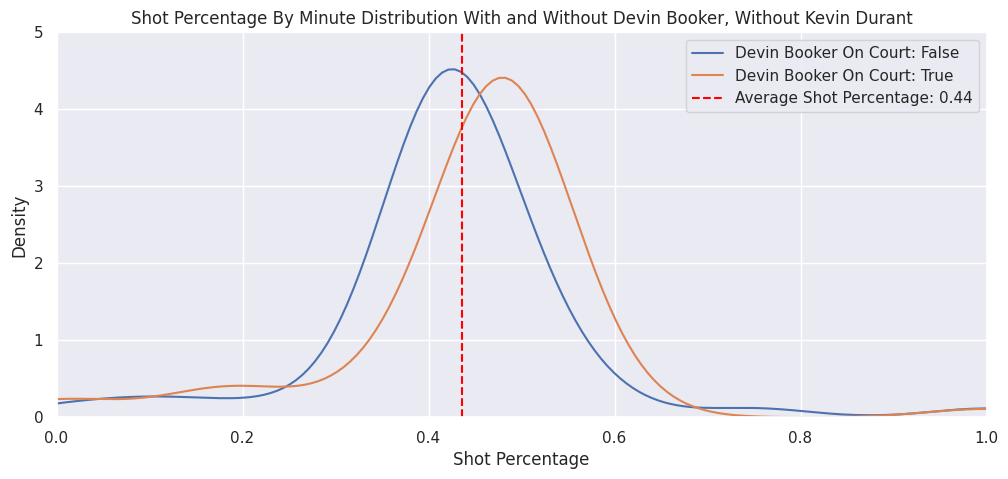

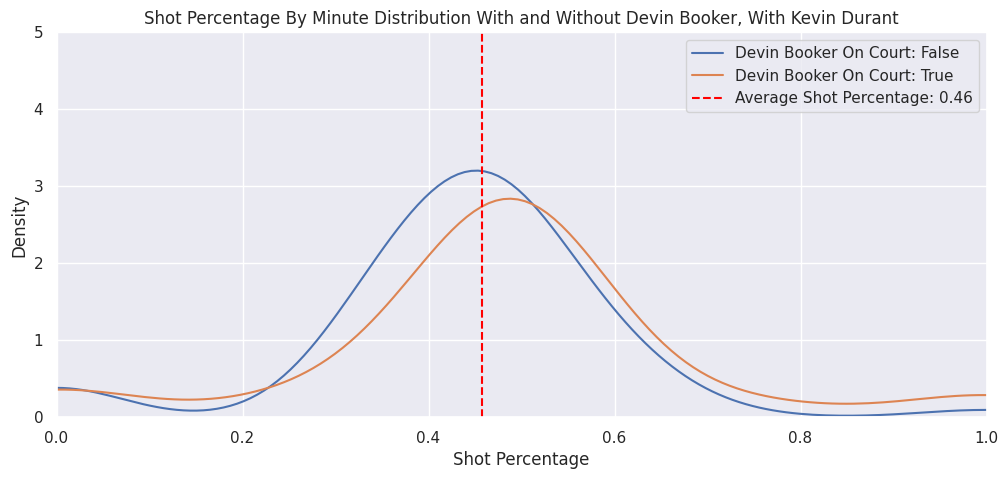

In [ ]:
plt.figure(figsize=(12, 5))

for db_on_val in pivot_table_suns_off_no_kd['db_on'].unique():
  subset = pivot_table_suns_off_no_kd[pivot_table_suns_off_no_kd['db_on'] == db_on_val]
  sns.kdeplot(subset['shot_pct'], label=f'Devin Booker On Court: {db_on_val}')

avg_shot_pct = pivot_table_suns_off_no_kd['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 5)
plt.title('Shot Percentage By Minute Distribution With and Without Devin Booker, Without Kevin Durant')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))

for db_on_val in pivot_table_suns_off_kd['db_on'].unique():
  subset = pivot_table_suns_off_kd[pivot_table_suns_off_kd['db_on'] == db_on_val]
  sns.kdeplot(subset['shot_pct'], label=f'Devin Booker On Court: {db_on_val}')

avg_shot_pct = pivot_table_suns_off_kd['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 5)
plt.title('Shot Percentage By Minute Distribution With and Without Devin Booker, With Kevin Durant')
plt.legend()
plt.show()

### Dbook Shot Distribution With and Without KD - 2022-2024

In [ ]:
booker_off_2224 = suns_off[(suns_off.db_on) & (suns_off.data_set.astype(str).apply(lambda x: '23' in x))].copy()
# get only plays where booker is involved in the action
booker_off_2224 = booker_off_2224[booker_off_2224.description.apply(lambda x: 'Booker' in x)]

In [ ]:
booker_off_2224['db_shot'] = (booker_off_2224.description.apply(lambda x: '(Booker' not in x)) \
      & (booker_off_2224['type'].apply(lambda x: 'shot' in x or 'layup' in x or 'fadeaway' in x or 'dunk' in x))

In [ ]:
booker_shot_2224 = booker_off_2224[(booker_off_2224.db_shot) | (booker_off_2224['type'].apply(lambda x: 'free throw' in x or 'technical' in x))].copy()
booker_shot_2224['FT'] = booker_shot_2224['type'].apply(lambda x: 'free throw' in x or 'technical' in x)
booker_shot_2224['FT_make'] = (booker_shot_2224.FT) & (booker_shot_2224.description.apply(lambda x: 'MISS' not in x))
booker_shot_2224['shot'] = ~booker_shot_2224.FT
booker_shot_2224['shot_make'] = booker_shot_2224.shot & (booker_shot_2224.description.apply(lambda x: 'MISS' not in x))

In [ ]:
booker_shot_2224['3PT'] = ((booker_shot_2224.shot_distance >= 22) & (booker_shot_2224['type'].apply(lambda x: '3pt' in x)))
booker_shot_2224['midrange'] = ((booker_shot_2224.shot_distance <= 24) & (booker_shot_2224.shot_distance > 10) & (booker_shot_2224['type'].apply(lambda x: '3pt' not in x)))
booker_shot_2224['close'] = (booker_shot_2224.shot_distance <= 10)

In [ ]:
# prompt: make a pivot for each shot distance category ('3PT', 'midrange', and 'close'), kd_on and summing shot and shot make

pivot_table_shot_distribution = pd.pivot_table(booker_shot_2224, values=['shot', 'shot_make'],
                                              index=['kd_on', '3PT', 'midrange', 'close', 'period_min'],
                                              aggfunc='sum').reset_index()

pivot_table_shot_distribution

,kd_on,3PT,midrange,close,period_min,shot,shot_make
0,False,False,False,False,1_10,0,0
1,False,False,False,False,1_11,0,0
2,False,False,False,False,1_2,0,0
3,False,False,False,False,1_3,0,0
4,False,False,False,False,1_4,0,0
...,...,...,...,...,...,...,...
372,True,True,False,False,4_7,14,5
373,True,True,False,False,4_8,8,1
374,True,True,False,False,4_9,7,3
375,True,True,False,False,5_3,1,0


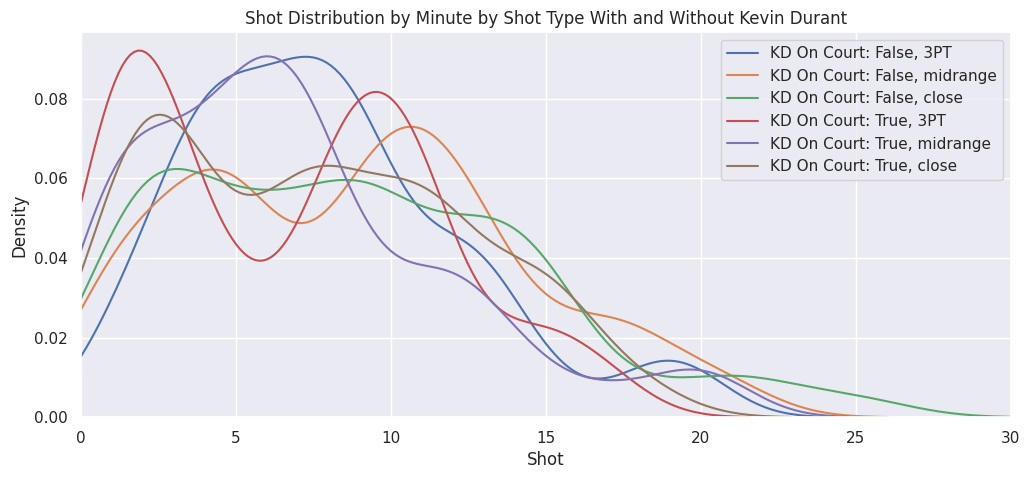

In [ ]:
# prompt: plot 'shot' kde distribution for kd on and off, normalizing y axis, for each category of shot

plt.figure(figsize=(12, 5))

for kd_on_val in pivot_table_shot_distribution['kd_on'].unique():
  for shot_type in ['3PT', 'midrange', 'close']:
    subset = pivot_table_shot_distribution[(pivot_table_shot_distribution['kd_on'] == kd_on_val) & (pivot_table_shot_distribution[shot_type])]
    if not subset.empty:
      shot_pct = subset['shot_make'] / subset['shot']
      sns.kdeplot(subset['shot'], bw_adjust=0.7, label=f'KD On Court: {kd_on_val}, {shot_type}')


plt.xlabel('Shot')
plt.xlim(0, 30)
plt.ylabel('Density')
plt.title('Shot Distribution by Minute by Shot Type With and Without Kevin Durant')
plt.legend()
plt.show()


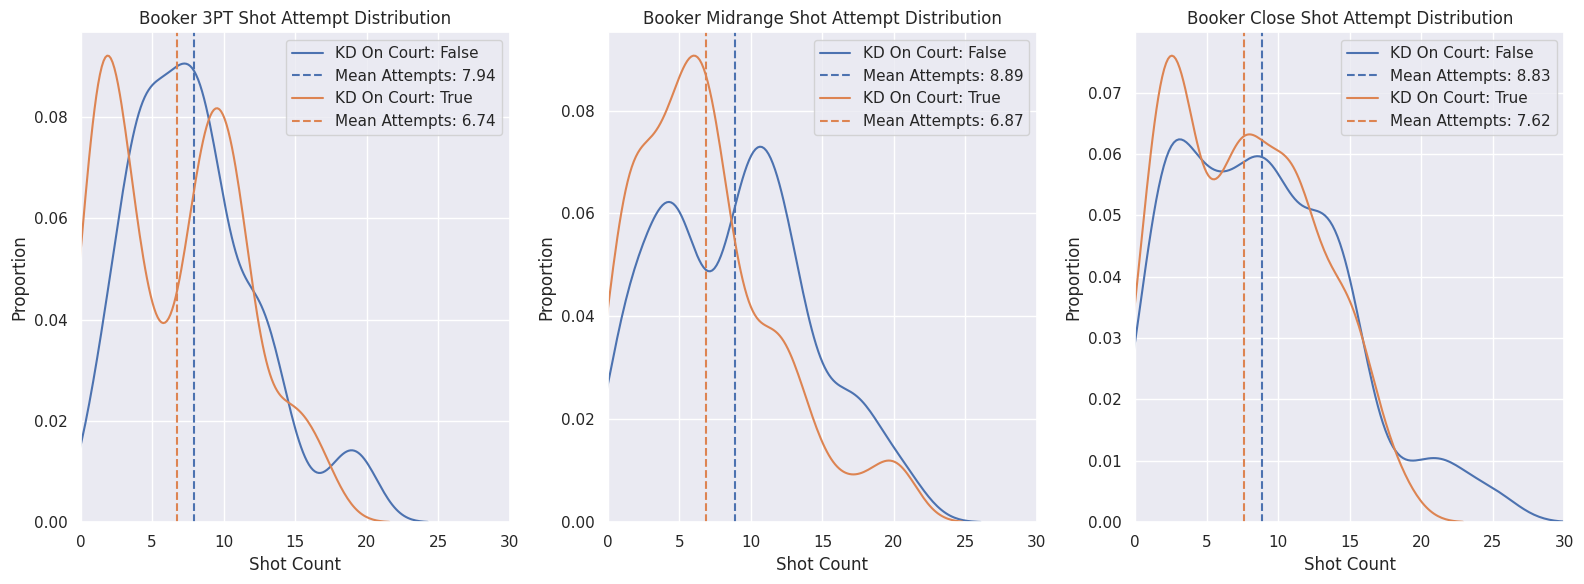

In [ ]:
# prompt: add a vertical line for the mean shot counts for each of the three plots above the same color as the respective kd_on_court value

# Assuming pivot_table_shot_distribution is defined as in your previous code

plt.figure(figsize=(16, 6))

for kd_on_val in pivot_table_shot_distribution['kd_on'].unique():
  plt.subplot(1, 3, 1)  # Subplot for 3PT shots
  for shot_type in ['3PT']:
    subset = pivot_table_shot_distribution[(pivot_table_shot_distribution['kd_on'] == kd_on_val) & (pivot_table_shot_distribution[shot_type])]
    if not subset.empty:
      shot_pct = subset['shot_make'] / subset['shot']
      sns.kdeplot(subset['shot'], bw_adjust=0.7, label=f'KD On Court: {kd_on_val}')
      mean_shot = subset['shot'].mean()
      plt.axvline(x=mean_shot, color='C1' if kd_on_val else 'C0', linestyle='--', label=f'Mean Attempts: {mean_shot:.2f}')
  plt.xlabel('Shot Count')
  plt.xlim(0, 30)
  plt.ylabel('Proportion')
  plt.title('Booker 3PT Shot Attempt Distribution')
  plt.legend()


  plt.subplot(1, 3, 2)  # Subplot for midrange shots
  for shot_type in ['midrange']:
    subset = pivot_table_shot_distribution[(pivot_table_shot_distribution['kd_on'] == kd_on_val) & (pivot_table_shot_distribution[shot_type])]
    if not subset.empty:
      shot_pct = subset['shot_make'] / subset['shot']
      sns.kdeplot(subset['shot'], bw_adjust=0.7, label=f'KD On Court: {kd_on_val}')
      mean_shot = subset['shot'].mean()
      plt.axvline(x=mean_shot, color='C1' if kd_on_val else 'C0', linestyle='--', label=f'Mean Attempts: {mean_shot:.2f}')
  plt.xlabel('Shot Count')
  plt.xlim(0, 30)
  plt.ylabel('Proportion')
  plt.title('Booker Midrange Shot Attempt Distribution')
  plt.legend()


  plt.subplot(1, 3, 3)  # Subplot for close shots
  for shot_type in ['close']:
    subset = pivot_table_shot_distribution[(pivot_table_shot_distribution['kd_on'] == kd_on_val) & (pivot_table_shot_distribution[shot_type])]
    if not subset.empty:
      shot_pct = subset['shot_make'] / subset['shot']
      sns.kdeplot(subset['shot'], bw_adjust=0.7, label=f'KD On Court: {kd_on_val}')
      mean_shot = subset['shot'].mean()
      plt.axvline(x=mean_shot, color='C1' if kd_on_val else 'C0', linestyle='--', label=f'Mean Attempts: {mean_shot:.2f}')
  plt.xlabel('Shot Count')
  plt.xlim(0, 30)
  plt.ylabel('Proportion')
  plt.title('Booker Close Shot Attempt Distribution')
  plt.legend(loc='best')

plt.tight_layout()  # Adjust subplot spacing
plt.show()


### How Proportion of Offensive Possessions Booker is Involved in With and Without KD

In [ ]:
suns_off['db_involved'] = suns_off.description.apply(lambda x: 'Booker' in x)
suns_off

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,matchup,game_name,db_on,PHX_offense,game_min,period_min,kd_on,misses,makes,db_involved
2288,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,False,False,False
2289,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,True,False,False
2292,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,False,False,False
2293,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,True,False,False
2298,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,1,1_1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607900,22301228,NBA 2023-2024 Regular Season,2023-12-08,Domantas Sabonis,Keon Ellis,Harrison Barnes,De'Aaron Fox,Malik Monk,Jordan Goodwin,Eric Gordon,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,False,False
607901,22301228,NBA 2023-2024 Regular Season,2023-12-08,Domantas Sabonis,Keon Ellis,Harrison Barnes,De'Aaron Fox,Malik Monk,Jordan Goodwin,Bol Bol,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,False,False
607906,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,True,False
607911,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,False,False


In [ ]:
pivot_table_suns_off_db_in = pd.pivot_table(suns_off[(suns_off['db_on']) & (suns_off.data_set.str.contains('23'))], values=['db_involved'], index=['kd_on', 'period_min'], aggfunc='mean').reset_index()
pivot_table_suns_off_db_in.describe()

,db_involved
count,121.000000
mean,0.288548
std,0.139652
min,0.000000
25%,0.240876
50%,0.267327
75%,0.321244
max,1.000000


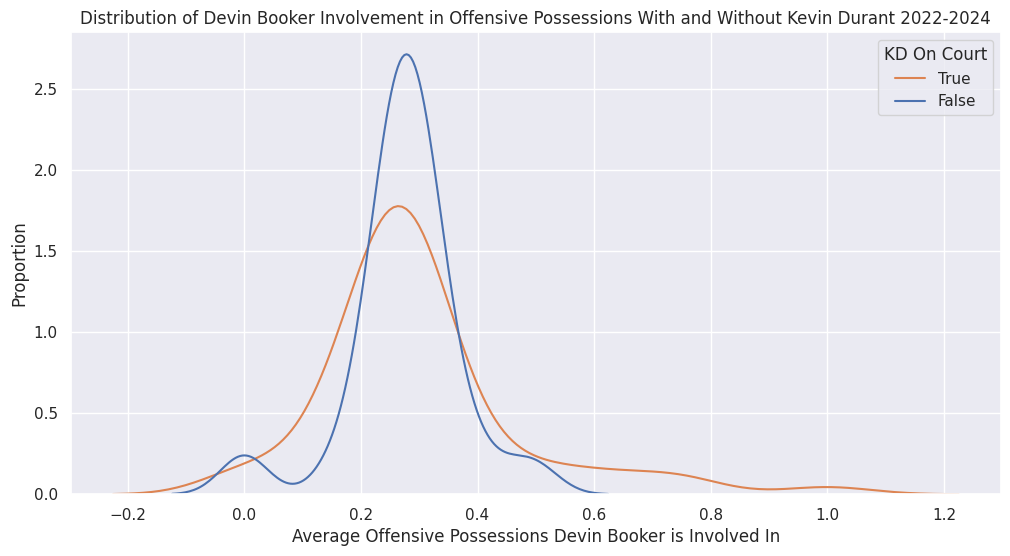

In [ ]:
# prompt: plot kde of db_involved for kd on and off

plt.figure(figsize=(12, 6))

sns.kdeplot(data=pivot_table_suns_off_db_in, x='db_involved', hue='kd_on')

plt.xlabel('Average Offensive Possessions Devin Booker is Involved In')
plt.ylabel('Proportion')
plt.title('Distribution of Devin Booker Involvement in Offensive Possessions With and Without Kevin Durant 2022-2024')
plt.legend(['True', 'False'], title='KD On Court')
plt.show()

In [ ]:
suns_off

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,matchup,game_name,db_on,PHX_offense,game_min,period_min,kd_on,misses,makes,db_involved
2288,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,False,False,False
2289,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,True,False,False
2292,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,False,False,False
2293,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,0,1_0,False,True,False,False
2298,22100331,2021-22 Regular Season,2021-12-02,Isaiah Stewart,Killian Hayes,Jerami Grant,Saddiq Bey,Cade Cunningham,Deandre Ayton,Mikal Bridges,...,DET@PHX,0022100331-DET@PHX,False,True,1,1_1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607900,22301228,NBA 2023-2024 Regular Season,2023-12-08,Domantas Sabonis,Keon Ellis,Harrison Barnes,De'Aaron Fox,Malik Monk,Jordan Goodwin,Eric Gordon,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,False,False
607901,22301228,NBA 2023-2024 Regular Season,2023-12-08,Domantas Sabonis,Keon Ellis,Harrison Barnes,De'Aaron Fox,Malik Monk,Jordan Goodwin,Bol Bol,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,False,False
607906,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,True,False
607911,22301228,NBA 2023-2024 Regular Season,2023-12-08,Chris Duarte,Keon Ellis,Davion Mitchell,Kessler Edwards,Sasha Vezenkov,Jordan Goodwin,Bol Bol,...,SAC@PHX,0022301228-SAC@PHX,False,True,11,4_11,False,False,False,False
